# End to End Machine Learning Pipeline

This notebook demonstrates a complete supervised machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, train/test split, cross-validation, model training, evaluation, calibration, interpretation, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
# Data overview

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nOutcome distribution:")
print(df["diabetes"].value_counts())

print("\nOutcome proportion:")
print(df["diabetes"].value_counts(normalize=True))

Dataset shape:
(100000, 9)

Column names:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows:
3854

Outcome distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Outcome proportion:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [7]:
# Data cleaning

df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Standardize column names
df_clean.columns = df_clean.columns.str.lower()

# Check unique values for categorical variables
print("Unique values in gender:")
print(df_clean["gender"].value_counts())

print("\nUnique values in smoking_history:")
print(df_clean["smoking_history"].value_counts())

print("\nCleaned dataset shape:")
print(df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nOutcome distribution after cleaning:")
print(df_clean["diabetes"].value_counts())

print("\nOutcome proportion after cleaning:")
print(df_clean["diabetes"].value_counts(normalize=True))

Unique values in gender:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Unique values in smoking_history:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

Cleaned dataset shape:
(96146, 9)

Missing values after cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hba1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Outcome distribution after cleaning:
diabetes
0    87664
1     8482
Name: count, dtype: int64

Outcome proportion after cleaning:
diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64


In [9]:
# Further cleaning for categorical variables

df_model = df_clean.copy()

# Remove very small gender category to simplify modeling
df_model = df_model[df_model["gender"] != "Other"].copy()

# Keep "No Info" in smoking_history as its own category
# because it may represent missing or unavailable smoking information.

print("Dataset shape after removing gender = Other:")
print(df_model.shape)

print("\nGender distribution:")
print(df_model["gender"].value_counts())

print("\nSmoking history distribution:")
print(df_model["smoking_history"].value_counts())

print("\nOutcome distribution:")
print(df_model["diabetes"].value_counts())

print("\nOutcome proportion:")
print(df_model["diabetes"].value_counts(normalize=True))

Dataset shape after removing gender = Other:
(96128, 9)

Gender distribution:
gender
Female    56161
Male      39967
Name: count, dtype: int64

Smoking history distribution:
smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64

Outcome distribution:
diabetes
0    87646
1     8482
Name: count, dtype: int64

Outcome proportion:
diabetes
0    0.911763
1    0.088237
Name: proportion, dtype: float64


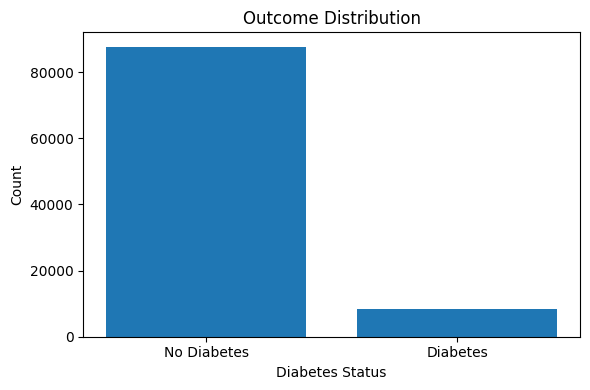

diabetes
0    87646
1     8482
Name: count, dtype: int64


In [11]:
# Visualization: outcome distribution

outcome_counts = df_model["diabetes"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Diabetes", "Diabetes"], outcome_counts.values)
plt.title("Outcome Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outcome_distribution.png", dpi=300)
plt.show()

print(outcome_counts)

In [13]:
# Numerical variable summary

numeric_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

print("Summary statistics for numerical variables:")
display(df_model[numeric_cols].describe())

Summary statistics for numerical variables:


,age,bmi,hba1c_level,blood_glucose_level
count,96128.000000,96128.000000,96128.000000,96128.000000
mean,41.796617,27.321450,5.532633,138.218001
std,22.463329,6.767811,1.073225,40.911190
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.400000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,59.000000,29.860000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


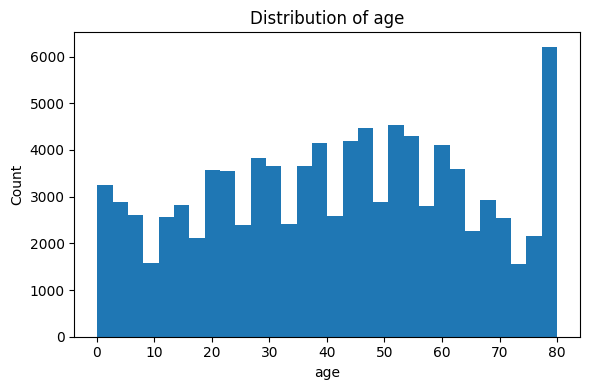

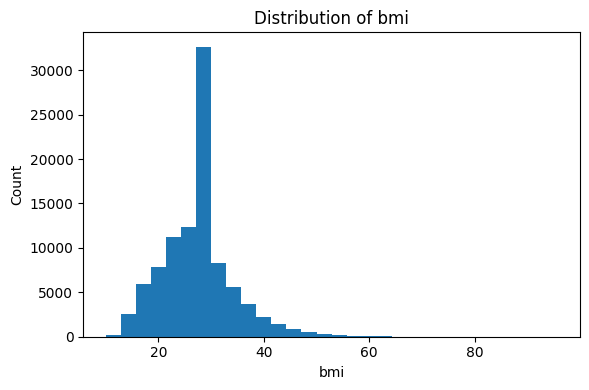

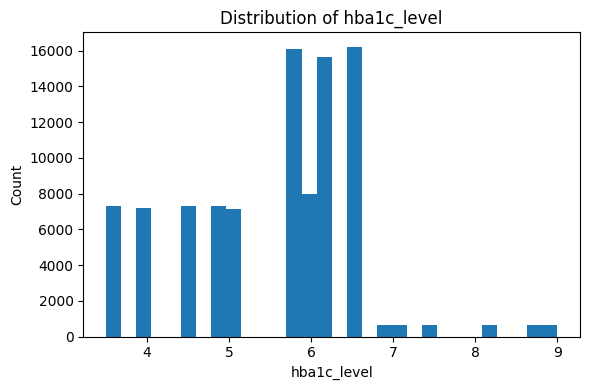

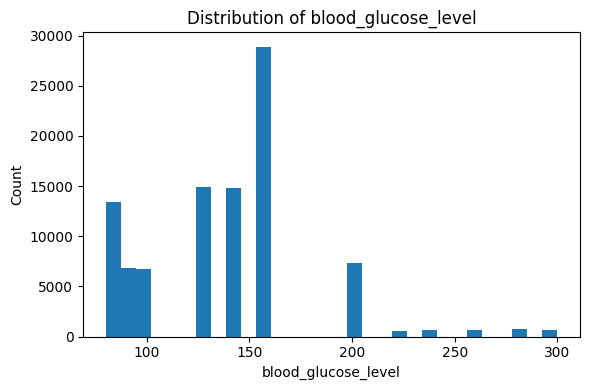

In [14]:
# Visualization: numerical variable distributions

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df_model[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"{col}_distribution.png", dpi=300)
    plt.show()

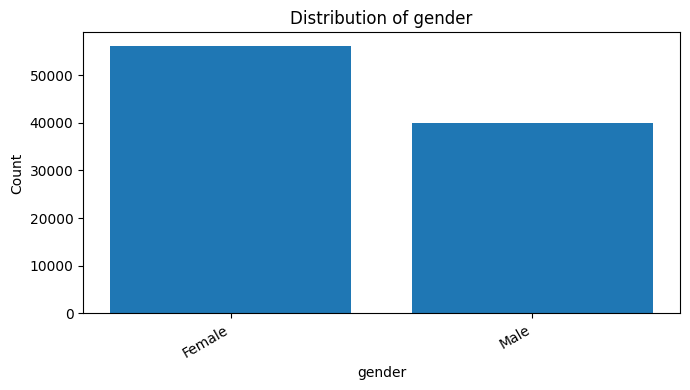


gender distribution:
gender
Female    56161
Male      39967
Name: count, dtype: int64


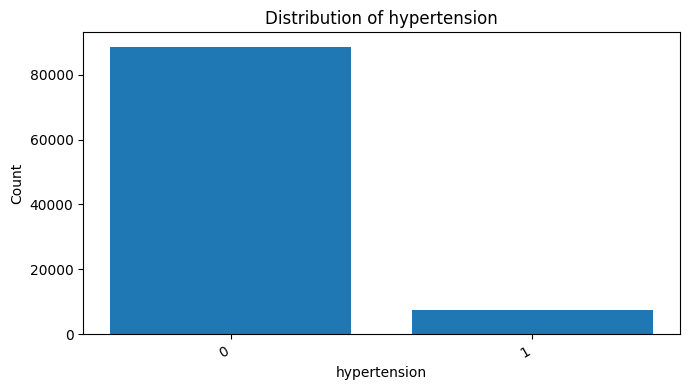


hypertension distribution:
hypertension
0    88667
1     7461
Name: count, dtype: int64


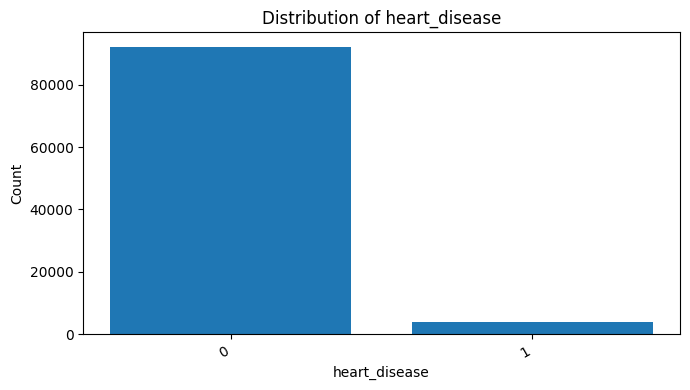


heart_disease distribution:
heart_disease
0    92205
1     3923
Name: count, dtype: int64


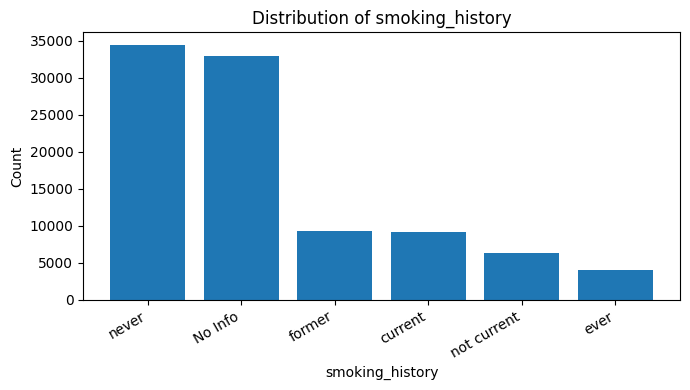


smoking_history distribution:
smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64


In [15]:
# Visualization: categorical variable distributions

categorical_cols = ["gender", "hypertension", "heart_disease", "smoking_history"]

for col in categorical_cols:
    counts = df_model[col].value_counts()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(f"{col}_distribution.png", dpi=300)
    plt.show()

    print(f"\n{col} distribution:")
    print(counts)

In [17]:
# Feature engineering

target = "diabetes"

X = df_model.drop(columns=[target])
y = df_model[target]

categorical_features = ["gender", "smoking_history"]
numeric_features = ["age", "bmi", "hba1c_level", "blood_glucose_level"]
binary_features = ["hypertension", "heart_disease"]

print("Target variable:")
print(target)

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

print("\nBinary features:")
print(binary_features)

print("\nFeature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nOutcome proportion:")
print(y.value_counts(normalize=True))

Target variable:
diabetes

Categorical features:
['gender', 'smoking_history']

Numerical features:
['age', 'bmi', 'hba1c_level', 'blood_glucose_level']

Binary features:
['hypertension', 'heart_disease']

Feature matrix shape:
(96128, 8)

Target shape:
(96128,)

Outcome proportion:
diabetes
0    0.911763
1    0.088237
Name: proportion, dtype: float64


In [18]:
# Train and test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature matrix shape:")
print(X_train.shape)

print("\nTesting feature matrix shape:")
print(X_test.shape)

print("\nTraining outcome proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting outcome proportion:")
print(y_test.value_counts(normalize=True))

Training feature matrix shape:
(76902, 8)

Testing feature matrix shape:
(19226, 8)

Training outcome proportion:
diabetes
0    0.911758
1    0.088242
Name: proportion, dtype: float64

Testing outcome proportion:
diabetes
0    0.911786
1    0.088214
Name: proportion, dtype: float64


In [19]:
# Preprocessing pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("binary", "passthrough", binary_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
# Model 1: Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic regression model fitted successfully.")

Logistic regression model fitted successfully.


In [21]:
# Logistic Regression: prediction and evaluation

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Predicted probability for the positive class
logistic_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Predicted class using default threshold = 0.5
logistic_pred = logistic_model.predict(X_test)

logistic_auc = roc_auc_score(y_test, logistic_pred_proba)
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)

print("Logistic Regression Performance")
print(f"AUC: {logistic_auc:.4f}")
print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall: {logistic_recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

Logistic Regression Performance
AUC: 0.9596
Accuracy: 0.8852
Precision: 0.4266
Recall: 0.8762

Confusion Matrix:
[[15533  1997]
 [  210  1486]]


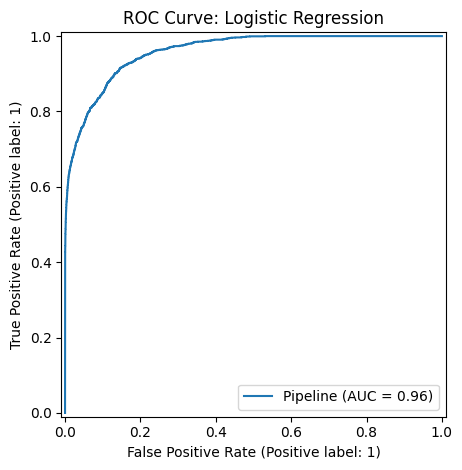

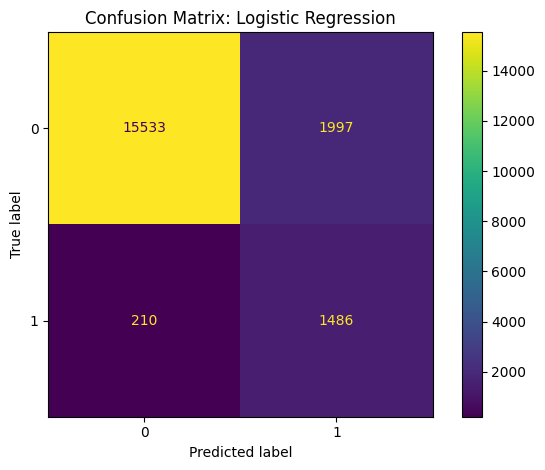

In [22]:
# Logistic Regression: ROC curve and confusion matrix visualization

RocCurveDisplay.from_estimator(logistic_model, X_test, y_test)
plt.title("ROC Curve: Logistic Regression")
plt.tight_layout()
plt.savefig("logistic_regression_roc_curve.png", dpi=300)
plt.show()

ConfusionMatrixDisplay.from_estimator(logistic_model, X_test, y_test)
plt.title("Confusion Matrix: Logistic Regression")
plt.tight_layout()
plt.savefig("logistic_regression_confusion_matrix.png", dpi=300)
plt.show()

In [23]:
# Model 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=20,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random forest model fitted successfully.")

Random forest model fitted successfully.


In [24]:
# Random Forest: prediction and evaluation

random_forest_pred_proba = random_forest_model.predict_proba(X_test)[:, 1]
random_forest_pred = random_forest_model.predict(X_test)

random_forest_auc = roc_auc_score(y_test, random_forest_pred_proba)
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_precision = precision_score(y_test, random_forest_pred)
random_forest_recall = recall_score(y_test, random_forest_pred)

print("Random Forest Performance")
print(f"AUC: {random_forest_auc:.4f}")
print(f"Accuracy: {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall: {random_forest_recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, random_forest_pred))

Random Forest Performance
AUC: 0.9736
Accuracy: 0.8999
Precision: 0.4653
Recall: 0.9062

Confusion Matrix:
[[15764  1766]
 [  159  1537]]


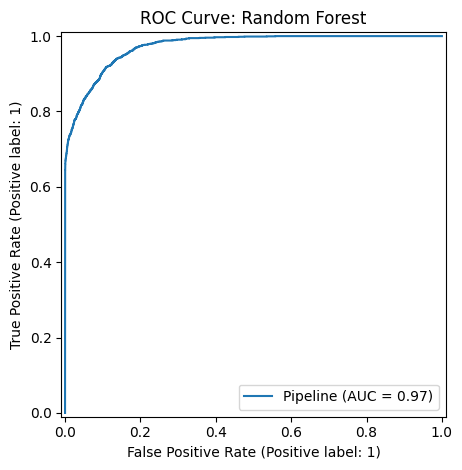

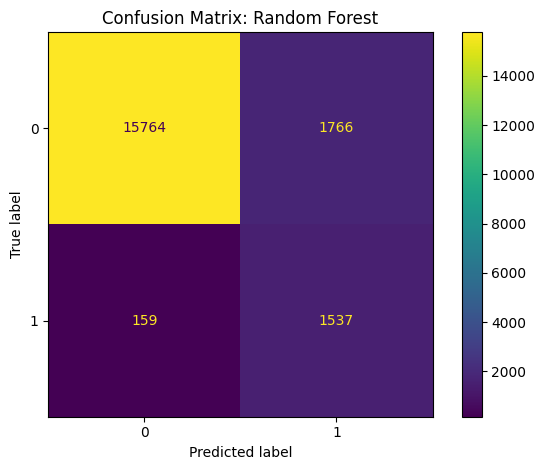

In [25]:
# Random Forest: ROC curve and confusion matrix visualization

RocCurveDisplay.from_estimator(random_forest_model, X_test, y_test)
plt.title("ROC Curve: Random Forest")
plt.tight_layout()
plt.savefig("random_forest_roc_curve.png", dpi=300)
plt.show()

ConfusionMatrixDisplay.from_estimator(random_forest_model, X_test, y_test)
plt.title("Confusion Matrix: Random Forest")
plt.tight_layout()
plt.savefig("random_forest_confusion_matrix.png", dpi=300)
plt.show()

In [26]:
# Model 3: XGBoost

from xgboost import XGBClassifier

# Calculate class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgboost_model.fit(X_train, y_train)

print("XGBoost model fitted successfully.")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

XGBoost model fitted successfully.
scale_pos_weight: 10.33


In [27]:
# XGBoost: prediction and evaluation

xgboost_pred_proba = xgboost_model.predict_proba(X_test)[:, 1]
xgboost_pred = xgboost_model.predict(X_test)

xgboost_auc = roc_auc_score(y_test, xgboost_pred_proba)
xgboost_accuracy = accuracy_score(y_test, xgboost_pred)
xgboost_precision = precision_score(y_test, xgboost_pred)
xgboost_recall = recall_score(y_test, xgboost_pred)

print("XGBoost Performance")
print(f"AUC: {xgboost_auc:.4f}")
print(f"Accuracy: {xgboost_accuracy:.4f}")
print(f"Precision: {xgboost_precision:.4f}")
print(f"Recall: {xgboost_recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgboost_pred))

XGBoost Performance
AUC: 0.9776
Accuracy: 0.9001
Precision: 0.4663
Recall: 0.9169

Confusion Matrix:
[[15750  1780]
 [  141  1555]]


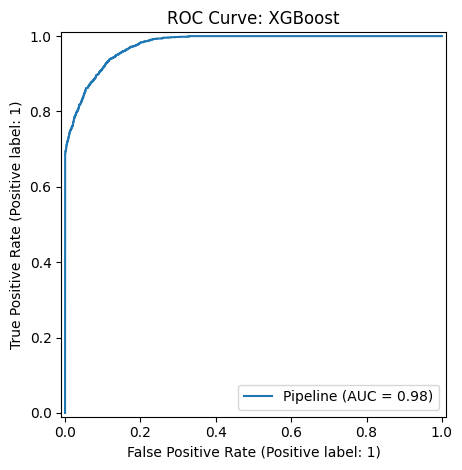

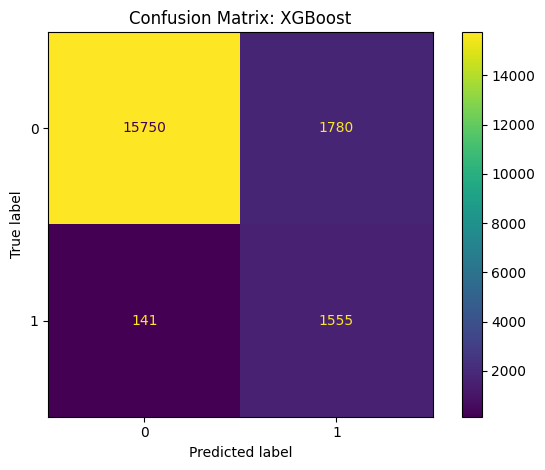

In [28]:
# XGBoost: ROC curve and confusion matrix visualization

RocCurveDisplay.from_estimator(xgboost_model, X_test, y_test)
plt.title("ROC Curve: XGBoost")
plt.tight_layout()
plt.savefig("xgboost_roc_curve.png", dpi=300)
plt.show()

ConfusionMatrixDisplay.from_estimator(xgboost_model, X_test, y_test)
plt.title("Confusion Matrix: XGBoost")
plt.tight_layout()
plt.savefig("xgboost_confusion_matrix.png", dpi=300)
plt.show()

In [29]:
# Model performance comparison

performance_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "AUC": [
        logistic_auc,
        random_forest_auc,
        xgboost_auc
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ],
    "Precision": [
        logistic_precision,
        random_forest_precision,
        xgboost_precision
    ],
    "Recall": [
        logistic_recall,
        random_forest_recall,
        xgboost_recall
    ]
})

performance_results = performance_results.round(4)

display(performance_results)

,Model,AUC,Accuracy,Precision,Recall
0,Logistic Regression,0.9596,0.8852,0.4266,0.8762
1,Random Forest,0.9736,0.8999,0.4653,0.9062
2,XGBoost,0.9776,0.9001,0.4663,0.9169


In [30]:
# Save performance comparison table

performance_results.to_csv("model_performance_comparison.csv", index=False)

print("Model performance comparison table saved successfully.")

Model performance comparison table saved successfully.


XGBoost achieved the best overall performance, with the highest AUC and recall. Random Forest also performed strongly and was close to XGBoost. Logistic Regression provided a useful interpretable baseline model. Because the dataset is imbalanced, recall is especially important for identifying diabetes cases, while the relatively lower precision indicates more false positives.

In [31]:
# Cross-validation comparison

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

cv_results = []

for model_name, model in models.items():
    auc_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV AUC": auc_scores.mean(),
        "SD CV AUC": auc_scores.std()
    })

cv_results = pd.DataFrame(cv_results).round(4)

display(cv_results)

,Model,Mean CV AUC,SD CV AUC
0,Logistic Regression,0.9624,0.0004
1,Random Forest,0.9755,0.0014
2,XGBoost,0.9797,0.0004


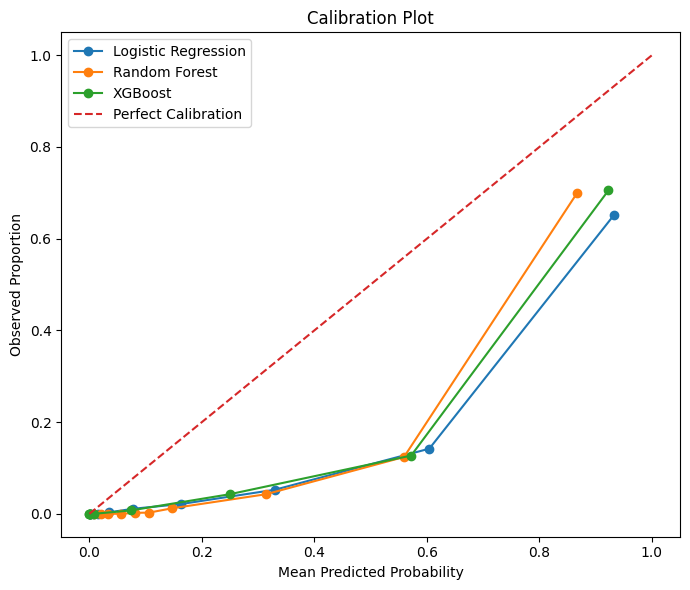

In [32]:
# Calibration plot comparison

from sklearn.calibration import calibration_curve

calibration_models = {
    "Logistic Regression": logistic_pred_proba,
    "Random Forest": random_forest_pred_proba,
    "XGBoost": xgboost_pred_proba
}

plt.figure(figsize=(7, 6))

for model_name, pred_proba in calibration_models.items():
    prob_true, prob_pred = calibration_curve(
        y_test,
        pred_proba,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(prob_pred, prob_true, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.title("Calibration Plot")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.legend()
plt.tight_layout()
plt.savefig("calibration_plot.png", dpi=300)
plt.show()

,Feature,Importance
2,numeric__hba1c_level,0.421076
3,numeric__blood_glucose_level,0.257208
0,numeric__age,0.097006
12,binary__hypertension,0.064770
13,binary__heart_disease,0.035353
1,numeric__bmi,0.034652
6,categorical__smoking_history_No Info,0.030971
4,categorical__gender_Female,0.016976
5,categorical__gender_Male,0.013146
11,categorical__smoking_history_not current,0.008209


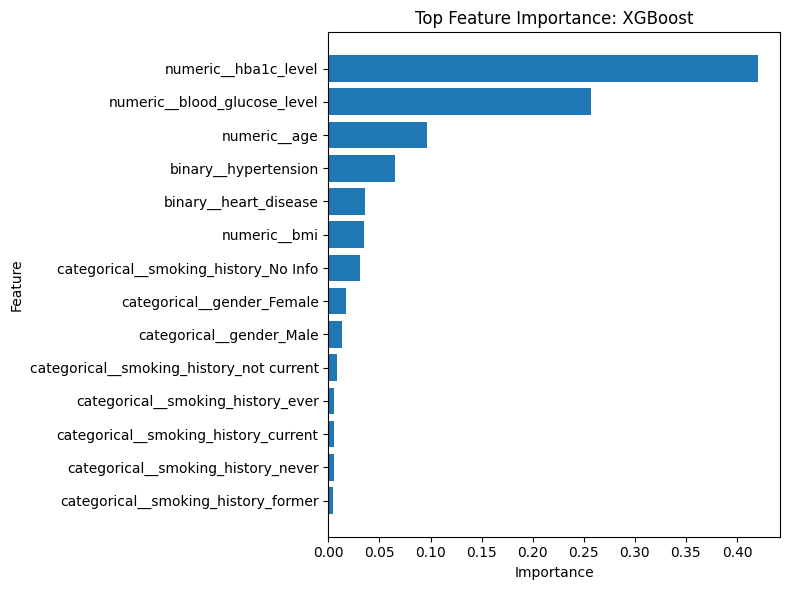

In [33]:
# XGBoost feature importance

# Get transformed feature names from the preprocessing step
feature_names = xgboost_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from the fitted XGBoost classifier
xgboost_importance = xgboost_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgboost_importance
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df)

# Plot top 15 features
top_features = feature_importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance: XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=300)
plt.show()

The most important predictors in the XGBoost model were HbA1c level, blood glucose level, age, hypertension, heart disease, and BMI. These findings are clinically reasonable because HbA1c and blood glucose are directly related to diabetes status, while age, hypertension, heart disease, and BMI are common diabetes risk related factors.

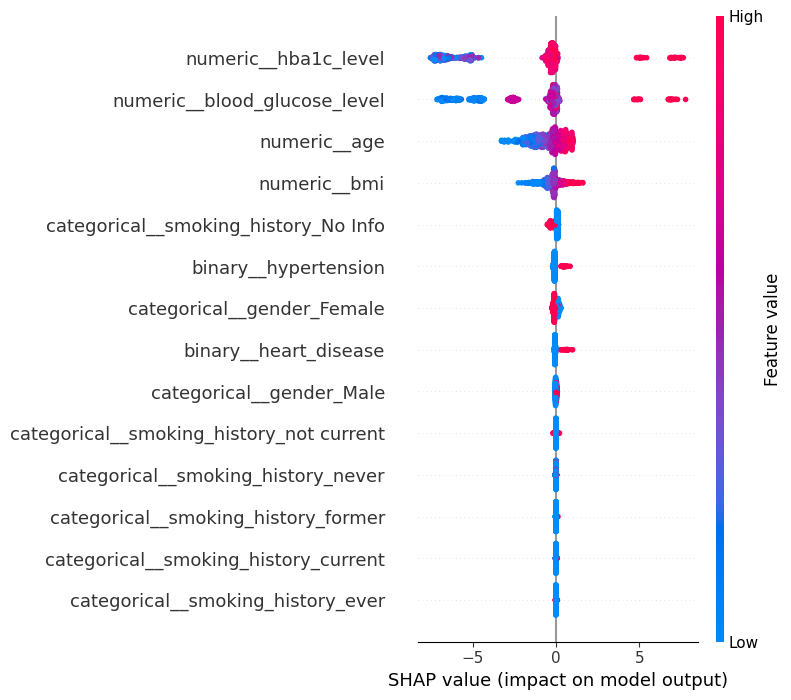

In [34]:
# SHAP interpretation for XGBoost

import shap

# Transform the test data using the fitted preprocessor
X_test_transformed = xgboost_model.named_steps["preprocessor"].transform(X_test)

# Convert transformed matrix to DataFrame for easier interpretation
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# Use a sample to make SHAP faster
X_test_sample = X_test_transformed_df.sample(
    n=1000,
    random_state=42
)

# Create SHAP explainer for the fitted XGBoost classifier
explainer = shap.TreeExplainer(xgboost_model.named_steps["classifier"])

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.tight_layout()
plt.savefig("xgboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary of Findings

This project demonstrated a complete supervised machine learning workflow for diabetes prediction using a publicly available health related dataset.

The workflow included data cleaning, exploratory data analysis, feature engineering, train and test split, preprocessing, model training, cross validation, model evaluation, calibration assessment, feature importance, SHAP interpretation, and visualization.

Three classification models were compared: logistic regression, random forest, and XGBoost. Logistic regression served as an interpretable baseline model, while random forest and XGBoost were used to capture nonlinear relationships and potential interactions among predictors.

On the held out test set, XGBoost achieved the best overall performance with the highest AUC and recall. Random forest also performed strongly and was close to XGBoost. Logistic regression provided a useful baseline and remained highly competitive in terms of AUC.

Cross validation results showed that model performance was stable across folds. XGBoost had the highest mean cross validated AUC, followed by random forest and logistic regression.

The most important predictors in the XGBoost model were HbA1c level, blood glucose level, age, hypertension, heart disease, and BMI. These findings are clinically reasonable because HbA1c and blood glucose are directly related to diabetes status, while age, hypertension, heart disease, and BMI are common diabetes risk related factors.

Because the outcome was imbalanced, recall was an important evaluation metric. The models were designed to improve identification of diabetes cases, which led to strong recall but relatively lower precision. In a healthcare screening context, this tradeoff can be acceptable because false negatives may be more concerning than false positives.

Overall, this project shows the ability to build a reproducible end to end machine learning pipeline, compare multiple models, evaluate classification performance, assess calibration, interpret predictors, and communicate results clearly.